## read the excel sheet

In [2]:
# import libraries 

import pandas as pd
import numpy as np
import json
import ast
import fuzzywuzzy
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
from datetime import datetime
from tqdm import tqdm 
from collections import defaultdict


c:\Users\tania\AppData\Local\Programs\Python\Python311\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [3]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
q1_raw = pd.read_excel('./cerc_results/overall comparison.xlsx', sheet_name="QUERY 1")
q2_raw = pd.read_excel('./cerc_results/overall comparison.xlsx', sheet_name="QUERY 2")
q3_raw = pd.read_excel('./cerc_results/overall comparison.xlsx', sheet_name="QUERY 3")

## deal with query 1

### clean query 1

In [5]:
q1_raw = q1_raw.rename(columns={"OA citation count ": "OA citation count", "SciVal titles ": "SciVal titles", "SV citation count ": "SV citation count"})
q1_raw.head()

,OpenAlex titles,OpenAlex DOI,OA citation count,SciVal titles,SciVal DOI,SV citation count,Unnamed: 6,Unnamed: 7,Total number of Publications,Unnamed: 9
0,Flood Detection and Susceptibility Mapping Usi...,10.3390/rs12020266,355.0,Planck 2018 results: V. CMB power spectra and ...,10.1051/0004-6361/201936386,788.0,NaN,NaN,OpenAlex,968.000000
1,SAPIEN: A SimulAted Part-Based Interactive ENv...,10.1109/cvpr42600.2020.01111,353.0,SuperYOLO: Super Resolution Assisted Object De...,10.1109/TGRS.2023.3258666,458.0,NaN,NaN,SciVal,950.000000
2,Changes in Annual Extremes of Daily Temperatur...,10.1175/jcli-d-19-1013.1,329.0,Sapien: A simulated part-based interactive ENv...,10.1109/CVPR42600.2020.01111,377.0,NaN,NaN,OA in SV %,0.662190
3,A processâ€based metacommunity framework link...,10.1111/ele.13568,323.0,Habitat 2.0: Training Home Assistants to Rearr...,NaN,319.0,NaN,NaN,SV in OA %,0.676842
4,SuperYOLO: Super Resolution Assisted Object De...,10.1109/tgrs.2023.3258666,284.0,Flood detection and susceptibility mapping usi...,10.3390/rs12020266,317.0,NaN,NaN,NaN,NaN


#### oa

In [6]:
q1_oa = q1_raw[['OpenAlex titles', 'OpenAlex DOI', 'OA citation count']].dropna(how="all")
q1_oa.head()

,OpenAlex titles,OpenAlex DOI,OA citation count
0,Flood Detection and Susceptibility Mapping Usi...,10.3390/rs12020266,355.0
1,SAPIEN: A SimulAted Part-Based Interactive ENv...,10.1109/cvpr42600.2020.01111,353.0
2,Changes in Annual Extremes of Daily Temperatur...,10.1175/jcli-d-19-1013.1,329.0
3,A processâ€based metacommunity framework link...,10.1111/ele.13568,323.0
4,SuperYOLO: Super Resolution Assisted Object De...,10.1109/tgrs.2023.3258666,284.0


In [7]:
oa_q1_stats = pd.DataFrame()
oa_q1_stats['database'] = ["OA"]
oa_q1_stats['query'] = ['Q1']
oa_q1_stats['count'] = [len(q1_oa)]
oa_q1_stats['have DOI'] = [len(q1_oa[q1_oa['OpenAlex DOI'].notna()])]
oa_q1_stats['mean citations'] = [np.mean(q1_oa['OA citation count'])]
oa_q1_stats['median citations'] = [np.median(q1_oa['OA citation count'].dropna())]
oa_q1_stats['q1 citations'] = [np.quantile(q1_oa['OA citation count'].dropna(), 0.25)]
oa_q1_stats['q3 citations'] = [np.quantile(q1_oa['OA citation count'].dropna(), 0.75)]

oa_q1_stats

,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,OA,Q1,968,965,13.216132,3.0,1.0,13.0


#### sv

In [8]:
q1_sv = q1_raw[['SciVal titles', 'SciVal DOI', 'SV citation count']].dropna(how="all")
q1_sv.head()

,SciVal titles,SciVal DOI,SV citation count
0,Planck 2018 results: V. CMB power spectra and ...,10.1051/0004-6361/201936386,788.0
1,SuperYOLO: Super Resolution Assisted Object De...,10.1109/TGRS.2023.3258666,458.0
2,Sapien: A simulated part-based interactive ENv...,10.1109/CVPR42600.2020.01111,377.0
3,Habitat 2.0: Training Home Assistants to Rearr...,NaN,319.0
4,Flood detection and susceptibility mapping usi...,10.3390/rs12020266,317.0


In [9]:
sv_q1_stats = pd.DataFrame()
sv_q1_stats['database'] = ["SV"]
sv_q1_stats['query'] = ['Q1']
sv_q1_stats['count'] = [len(q1_sv)]
sv_q1_stats['have DOI'] = [len(q1_sv[q1_sv['SciVal DOI'].notna()])]
sv_q1_stats['mean citations'] = [np.mean(q1_sv['SV citation count'])]
sv_q1_stats['median citations'] = [np.median(q1_sv['SV citation count'].dropna())]
sv_q1_stats['q1 citations'] = [np.quantile(q1_sv['SV citation count'].dropna(), 0.25)]
sv_q1_stats['q3 citations'] = [np.quantile(q1_sv['SV citation count'].dropna(), 0.75)]

sv_q1_stats

,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,SV,Q1,950,916,17.748421,6.0,2.0,17.0


### analysis of q1

## deal with q2

### clean query2

In [10]:
print(q2_raw.columns)

Index(['OpenAlex Title ', 'OpenAlex DOI', 'OpenAlex Citations', 'SciVal Title',
       'SciVal DOI', 'SciVal Citations', 'Unnamed: 6',
       'Total number of Publications', 'Unnamed: 8'],
      dtype='object')


In [11]:
q2_raw = q2_raw.rename(columns={"OpenAlex Title ": "OpenAlex Title"})
q2_raw.head()

,OpenAlex Title,OpenAlex DOI,OpenAlex Citations,SciVal Title,SciVal DOI,SciVal Citations,Unnamed: 6,Total number of Publications,Unnamed: 8
0,Functional and versatile superhydrophobic coat...,10.1038/s41467-021-21219-y,294.0,Functional and versatile superhydrophobic coat...,10.1038/s41467-021-21219-y,279,NaN,OpenAlex,199.000000
1,A review of primary technologies of thin-film ...,10.1088/2631-8695/ac2353,124.0,Opioid agonist treatment and risk of mortality...,10.1136/bmj.m772,170,NaN,SciVal,329.000000
2,Phase transition enhanced superior elasticity ...,10.1126/sciadv.aba5847,123.0,Optical observation of single spins in silicon,10.1038/s41586-022-04821-y,142,NaN,OA in SV %,0.748744
3,Material properties and structure of natural g...,10.1038/s41598-020-75393-y,82.0,"Dimensional diversity (0D, 1D, 2D, and 3D) in ...",10.1039/d3ta06953b,122,NaN,SV in OA %,0.452888
4,Recent progress in bismuth-based high Curie te...,10.1016/j.cossms.2022.101016,73.0,A review of primary technologies of thin-film ...,10.1088/2631-8695/ac2353,121,NaN,NaN,NaN


#### oa

In [12]:
q2_oa = q2_raw[['OpenAlex Title', 'OpenAlex DOI', 'OpenAlex Citations']].dropna(how="all")
q2_oa.head()

,OpenAlex Title,OpenAlex DOI,OpenAlex Citations
0,Functional and versatile superhydrophobic coat...,10.1038/s41467-021-21219-y,294.0
1,A review of primary technologies of thin-film ...,10.1088/2631-8695/ac2353,124.0
2,Phase transition enhanced superior elasticity ...,10.1126/sciadv.aba5847,123.0
3,Material properties and structure of natural g...,10.1038/s41598-020-75393-y,82.0
4,Recent progress in bismuth-based high Curie te...,10.1016/j.cossms.2022.101016,73.0


In [13]:
oa_q2_stats = pd.DataFrame()
oa_q2_stats['database'] = ["OA"]
oa_q2_stats['query'] = ['Q2']
oa_q2_stats['count'] = [len(q2_oa)]
oa_q2_stats['have DOI'] = [len(q2_oa[q2_oa['OpenAlex DOI'].notna()])]
oa_q2_stats['mean citations'] = [np.mean(q2_oa['OpenAlex Citations'])]
oa_q2_stats['median citations'] = [np.median(q2_oa['OpenAlex Citations'].dropna())]
oa_q2_stats['q1 citations'] = [np.quantile(q2_oa['OpenAlex Citations'].dropna(), 0.25)]
oa_q2_stats['q3 citations'] = [np.quantile(q2_oa['OpenAlex Citations'].dropna(), 0.75)]

oa_q2_stats

,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,OA,Q2,199,199,16.823232,5.5,1.0,22.0


#### sv

In [14]:
q2_sv = q2_raw[['SciVal Title', 'SciVal DOI', 'SciVal Citations']].dropna(how="all")
q2_sv.head()

,SciVal Title,SciVal DOI,SciVal Citations
0,Functional and versatile superhydrophobic coat...,10.1038/s41467-021-21219-y,279
1,Opioid agonist treatment and risk of mortality...,10.1136/bmj.m772,170
2,Optical observation of single spins in silicon,10.1038/s41586-022-04821-y,142
3,"Dimensional diversity (0D, 1D, 2D, and 3D) in ...",10.1039/d3ta06953b,122
4,A review of primary technologies of thin-film ...,10.1088/2631-8695/ac2353,121


In [15]:
sv_q2_stats = pd.DataFrame()
sv_q2_stats['database'] = ["SV"]
sv_q2_stats['query'] = ['Q2']
sv_q2_stats['count'] = [len(q2_sv)]
sv_q2_stats['have DOI'] = [len(q2_sv[q2_sv['SciVal DOI'].notna()])]
sv_q2_stats['mean citations'] = [np.mean(q2_sv['SciVal Citations'])]
sv_q2_stats['median citations'] = [np.median(q2_sv['SciVal Citations'].dropna())]
sv_q2_stats['q1 citations'] = [np.quantile(q2_sv['SciVal Citations'].dropna(), 0.25)]
sv_q2_stats['q3 citations'] = [np.quantile(q2_sv['SciVal Citations'].dropna(), 0.75)]

sv_q2_stats

,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,SV,Q2,329,329,18.559271,9.0,3.0,22.0


### analysis of q2

## deal with q3

### clean query 3

In [16]:
print(q3_raw.columns)

Index(['OpenAlex Title ', 'OpenAlex DOI', 'OpenAlex Citations',
       'SciVal Title ', 'SciVal DOI', 'SciVal Citations', 'Unnamed: 6',
       'Total number of Publications', 'Unnamed: 8'],
      dtype='object')


In [17]:
q3_raw = q3_raw.rename(columns={"OpenAlex Title ": "OpenAlex Title", "SciVal Title ": "SciVal Title"})
q3_raw.head()

,OpenAlex Title,OpenAlex DOI,OpenAlex Citations,SciVal Title,SciVal DOI,SciVal Citations,Unnamed: 6,Total number of Publications,Unnamed: 8
0,COVID-19: the gendered impacts of the outbreak,10.1016/s0140-6736(20)30526-2,1743.0,The Lancet Commission on lessons for the futur...,10.1016/S0140-6736(22)01585-9,601,NaN,OpenAlex,718.000000
1,Human resource management in the age of genera...,10.1111/1748-8583.12524,671.0,Human resource management in the age of genera...,10.1111/1748-8583.12524,600,NaN,SciVal,768.000000
2,Mobilizing Policy (In)Capacity to Fight COVID-...,10.1080/14494035.2020.1787628,553.0,Mobilizing Policy (In)Capacity to Fight COVID-...,10.1080/14494035.2020.1787628,445,NaN,OA in SV %,0.600279
3,How Right-Leaning Media Coverage of COVID-19 F...,10.1017/s0008423920000396,441.0,How right-leaning media coverage of Covid-19 f...,10.1017/S0008423920000396,341,NaN,SV in OA %,0.559896
4,Digital agricultural technologies for food los...,10.1016/j.jclepro.2021.129099,203.0,The Knowns and Unknowns of Policy Instrument A...,10.1177/2158244019900568,297,NaN,NaN,NaN


#### oa

In [18]:
q3_oa = q3_raw[['OpenAlex Title', 'OpenAlex DOI', 'OpenAlex Citations']].dropna(how="all")
q3_oa.head()

,OpenAlex Title,OpenAlex DOI,OpenAlex Citations
0,COVID-19: the gendered impacts of the outbreak,10.1016/s0140-6736(20)30526-2,1743.0
1,Human resource management in the age of genera...,10.1111/1748-8583.12524,671.0
2,Mobilizing Policy (In)Capacity to Fight COVID-...,10.1080/14494035.2020.1787628,553.0
3,How Right-Leaning Media Coverage of COVID-19 F...,10.1017/s0008423920000396,441.0
4,Digital agricultural technologies for food los...,10.1016/j.jclepro.2021.129099,203.0


In [19]:
oa_q3_stats = pd.DataFrame()
oa_q3_stats['database'] = ["OA"]
oa_q3_stats['query'] = ['Q3']
oa_q3_stats['count'] = [len(q3_oa)]
oa_q3_stats['have DOI'] = [len(q3_oa[q3_oa['OpenAlex DOI'].notna()])]
oa_q3_stats['mean citations'] = [np.mean(q3_oa['OpenAlex Citations'])]
oa_q3_stats['median citations'] = [np.median(q3_oa['OpenAlex Citations'].dropna())]
oa_q3_stats['q1 citations'] = [np.quantile(q3_oa['OpenAlex Citations'].dropna(), 0.25)]
oa_q3_stats['q3 citations'] = [np.quantile(q3_oa['OpenAlex Citations'].dropna(), 0.75)]

oa_q3_stats

,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,OA,Q3,718,712,16.239554,3.0,0.0,13.0


#### sv

In [20]:
q3_sv = q3_raw[['SciVal Title', 'SciVal DOI', 'SciVal Citations']].dropna(how="all")
q3_sv.head()

,SciVal Title,SciVal DOI,SciVal Citations
0,The Lancet Commission on lessons for the futur...,10.1016/S0140-6736(22)01585-9,601
1,Human resource management in the age of genera...,10.1111/1748-8583.12524,600
2,Mobilizing Policy (In)Capacity to Fight COVID-...,10.1080/14494035.2020.1787628,445
3,How right-leaning media coverage of Covid-19 f...,10.1017/S0008423920000396,341
4,The Knowns and Unknowns of Policy Instrument A...,10.1177/2158244019900568,297


In [21]:
sv_q3_stats = pd.DataFrame()
sv_q3_stats['database'] = ["SV"]
sv_q3_stats['query'] = ['Q3']
sv_q3_stats['count'] = [len(q3_sv)]
sv_q3_stats['have DOI'] = [len(q3_sv[q3_sv['SciVal DOI'].notna()])]
sv_q3_stats['mean citations'] = [np.mean(q3_sv['SciVal Citations'])]
sv_q3_stats['median citations'] = [np.median(q3_sv['SciVal Citations'].dropna())]
sv_q3_stats['q1 citations'] = [np.quantile(q3_sv['SciVal Citations'].dropna(), 0.25)]
sv_q3_stats['q3 citations'] = [np.quantile(q3_sv['SciVal Citations'].dropna(), 0.75)]

sv_q3_stats

,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,SV,Q3,768,768,16.861979,6.0,2.0,17.0


### analysis of q3

## add up results

In [22]:
descriptive_stats = pd.DataFrame()
descriptive_stats = pd.concat([oa_q1_stats, sv_q1_stats, oa_q2_stats, sv_q2_stats, oa_q3_stats, sv_q3_stats]).reset_index().drop(columns=['index'])

descriptive_stats

,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,OA,Q1,968,965,13.216132,3.0,1.0,13.0
1,SV,Q1,950,916,17.748421,6.0,2.0,17.0
2,OA,Q2,199,199,16.823232,5.5,1.0,22.0
3,SV,Q2,329,329,18.559271,9.0,3.0,22.0
4,OA,Q3,718,712,16.239554,3.0,0.0,13.0
5,SV,Q3,768,768,16.861979,6.0,2.0,17.0


## venn diagrams

In [23]:
import matplotlib as plt
from matplotlib_venn import venn2

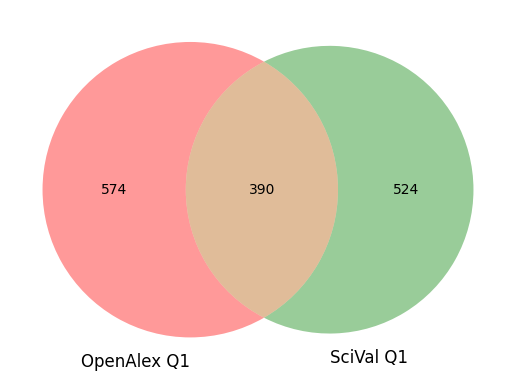

In [24]:
q1_comp = venn2([set(q1_oa['OpenAlex DOI'].dropna()), set(q1_sv['SciVal DOI'].dropna())],
      set_labels=('OpenAlex Q1', 'SciVal Q1'))

q1_comp

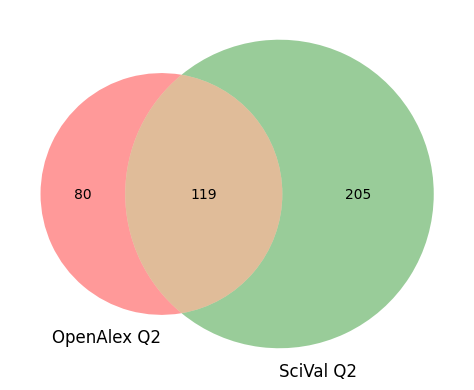

In [25]:
q2_comp = venn2([set(q2_oa['OpenAlex DOI'].dropna()), set(q2_sv['SciVal DOI'].dropna())],
      set_labels=('OpenAlex Q2', 'SciVal Q2'))

q2_comp

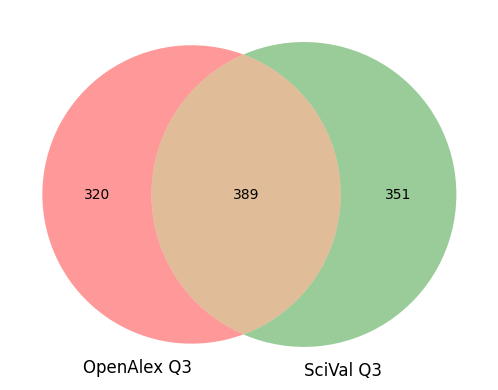

In [26]:
q3_comp = venn2([set(q3_oa['OpenAlex DOI'].dropna()), set(q3_sv['SciVal DOI'].dropna())],
      set_labels=('OpenAlex Q3', 'SciVal Q3'))

q3_comp

## look at intersect set stats

### q1

In [37]:
q1_merged = q1_sv.dropna(subset=['SciVal DOI']).merge(q1_oa.dropna(subset=['OpenAlex DOI']), left_on='SciVal DOI', right_on='OpenAlex DOI', how='inner')
q1_merged = q1_merged.drop(columns=['OpenAlex titles', 'OpenAlex DOI'])
q1_merged = q1_merged.rename(columns={'SciVal titles': 'Title', 'SciVal DOI': 'DOI'})

q1_merged

,Title,DOI,SV citation count,OA citation count
0,Planck 2018 results: V. CMB power spectra and ...,10.1051/0004-6361/201936386,788.0,0.0
1,Flood detection and susceptibility mapping usi...,10.3390/rs12020266,317.0,355.0
2,A process-based metacommunity framework linkin...,10.1111/ele.13568,255.0,323.0
3,"Quantum critical dynamics in a 5,000-qubit pro...",10.1038/s41586-023-05867-2,173.0,217.0
4,Coherent quantum annealing in a programmable 2...,10.1038/s41567-022-01741-6,165.0,199.0
...,...,...,...,...
388,Evaluation of MODIS-based Vegetation Restorati...,10.1051/e3sconf/202130802005,0.0,0.0
389,Reluctant and Illegal Migrants in Mao's China:...,10.1017/jch.2020.49,0.0,0.0
390,MODELLING AND SIMULATION OF SUSTAINABLE SYSTEM...,10.24908/pceea.vi0.14897,0.0,0.0
391,Crowd Management of Honda Celebration of Light...,10.1007/978-3-030-63089-8_6,0.0,1.0


In [44]:
q1_merged_stats = pd.DataFrame()
q1_merged_stats['Query'] = ['1']
q1_merged_stats['OA mean citations'] = [q1_merged['OA citation count'].mean()]
q1_merged_stats['SV mean citations'] = [q1_merged['SV citation count'].mean()]
q1_merged_stats['OA median citations'] = [q1_merged['OA citation count'].median()]
q1_merged_stats['SV median citations'] = [q1_merged['SV citation count'].median()]

q1_merged_stats

,Query,OA mean citations,SV mean citations,OA median citations,SV median citations
0,1,18.70229,18.951654,8.0,7.0


### q2

In [48]:
q2_merged = q2_sv.dropna(subset=['SciVal DOI']).merge(q2_oa.dropna(subset=['OpenAlex DOI']), left_on='SciVal DOI', right_on='OpenAlex DOI', how='inner')
q2_merged = q2_merged.drop(columns=['OpenAlex Title', 'OpenAlex DOI'])
q2_merged = q2_merged.rename(columns={'SciVal titles': 'Title', 'SciVal DOI': 'DOI'})

q2_merged

,SciVal Title,DOI,SciVal Citations,OpenAlex Citations
0,Functional and versatile superhydrophobic coat...,10.1038/s41467-021-21219-y,279,294.0
1,A review of primary technologies of thin-film ...,10.1088/2631-8695/ac2353,121,124.0
2,Phase transition enhanced superior elasticity ...,10.1126/sciadv.aba5847,89,123.0
3,Review of transfer learning in modeling additi...,10.1016/j.addma.2022.103357,77,67.0
4,Recent progress in bismuth-based high Curie te...,10.1016/j.cossms.2022.101016,73,73.0
...,...,...,...,...
114,Solvent selection in physical supercritical fl...,10.1016/j.supflu.2023.105939,1,1.0
115,Ontological how and why: action and objective ...,10.3389/frai.2023.1137961,1,1.0
116,Benchtop One-to-One Nanocontact Replication Ac...,10.1002/adem.202100048,1,1.0
117,A novel membrane-based absorber for sorption h...,10.1016/j.renene.2024.121338,0,0.0


In [54]:
q2_merged_stats = pd.DataFrame()
q2_merged_stats['Query'] = ['2']
q2_merged_stats['OA mean citations'] = [q2_merged['OpenAlex Citations'].mean()]
q2_merged_stats['SV mean citations'] = [q2_merged['SciVal Citations'].mean()]
q2_merged_stats['OA median citations'] = [q2_merged['OpenAlex Citations'].median()]
q2_merged_stats['SV median citations'] = [q2_merged['SciVal Citations'].median()]

q2_merged_stats

,Query,OA mean citations,SV mean citations,OA median citations,SV median citations
0,2,24.756303,23.117647,14.0,15.0


### q3

In [52]:
q3_merged = q3_sv.dropna(subset=['SciVal DOI']).merge(q3_oa.dropna(subset=['OpenAlex DOI']), left_on='SciVal DOI', right_on='OpenAlex DOI', how='inner')
q3_merged = q3_merged.drop(columns=['OpenAlex Title', 'OpenAlex DOI'])
q3_merged = q3_merged.rename(columns={'SciVal titles': 'Title', 'SciVal DOI': 'DOI'})

q3_merged

,SciVal Title,DOI,SciVal Citations,OpenAlex Citations
0,Human resource management in the age of genera...,10.1111/1748-8583.12524,600,671.0
1,Mobilizing Policy (In)Capacity to Fight COVID-...,10.1080/14494035.2020.1787628,445,553.0
2,Digital agricultural technologies for food los...,10.1016/j.jclepro.2021.129099,182,203.0
3,A large-scale test of the link between intergr...,10.1038/s41562-019-0815-z,159,0.0
4,How populism and conservative media fuel consp...,10.1177/2053168021993979,147,175.0
...,...,...,...,...
387,The commodification of mobile communications i...,10.1007/978-3-030-54169-9_7,0,0.0
388,Array of services for homeless mentally ill in...,10.7870/cjcmh-2020-028,0,0.0
389,"Tar & Feathers: Agnotology, Dissent, and Queer...",10.33182/ijor.v1i1.1104,0,0.0
390,Traumatic Brain Injury: An Underappreciated De...,10.1016/j.wneu.2020.02.133,0,1.0


In [55]:
q3_merged_stats = pd.DataFrame()
q3_merged_stats['Query'] = ['3']
q3_merged_stats['OA mean citations'] = [q3_merged['OpenAlex Citations'].mean()]
q3_merged_stats['SV mean citations'] = [q3_merged['SciVal Citations'].mean()]
q3_merged_stats['OA median citations'] = [q3_merged['OpenAlex Citations'].median()]
q3_merged_stats['SV median citations'] = [q3_merged['SciVal Citations'].median()]

q3_merged_stats

,Query,OA mean citations,SV mean citations,OA median citations,SV median citations
0,3,19.122449,17.390306,8.0,7.0


### overall

In [56]:
intersect_stats = pd.DataFrame()
intersect_stats = pd.concat([q1_merged_stats, q2_merged_stats, q3_merged_stats]).reset_index().drop(columns=['index'])

intersect_stats

,Query,OA mean citations,SV mean citations,OA median citations,SV median citations
0,1,18.702290,18.951654,8.0,7.0
1,2,24.756303,23.117647,14.0,15.0
2,3,19.122449,17.390306,8.0,7.0


Based on the fact that the intersect of the two sets has similar mean and median citations in both openalex and scival, we can assume that the difference in overall citation counts comes from the non-intersecting publications, i.e. the publications in SciVal which are not in OpenAlex have more citations than the publications which are in OpenAlex which are not in SciVal

## detailed visualizations

### query 1 
- for works in both OA and SV, plot citation counts